# PTB-XL ECG Machine Learning Capstone: Classification Track (Part A)
## Objective: Predicting Dominant Cardiac Diagnostic Category from 12-Lead ECG Features

This notebook implements **Classification Track Part A** under the Capstone rubric:
1. **Dataset & Exploratory Data Analysis (EDA)**: Single-label clinical priority collapsing ($\text{MI} > \text{CD} > \text{HYP} > \text{STTC} > \text{NORM}$), class balance distributions, feature profiles, and patient-stratified 80:20 split.
2. **Preprocessing & Feature Engineering**: Median imputation fit strictly on train, StandardScaler standardization, and the engineered repolarization-depolarization ratio (`qtc_qrs_ratio`).
3. **Part A Model Benchmarking (5 Algorithms)**:
   - Logistic Regression (multinomial with odds ratio analysis)
   - K-Nearest Neighbors (distance-weighted, tuned $k$)
   - Gaussian Naive Bayes (critical examination of conditional-independence assumptions)
   - Decision Tree Classifier (tuned `max_depth` with tree visualization)
   - Support Vector Classifier (RBF kernel with tuned $C$)
4. **Validation & Diagnostics**: Comprehensive comparison table reporting Accuracy and Weighted-F1, paired with full $5\times 5$ confusion matrix heatmaps.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
palette = sns.color_palette('Set2')

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries and plotting configuration loaded!")


Libraries and plotting configuration loaded!


---
## Section A: Dataset Ingestion, Single-Label Hierarchy & EDA


In [2]:
# 1. Ingest datasets
DATA_DIR = '../data'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)
features_df = pd.read_csv(os.path.join(DATA_DIR, 'stage4_features.csv'))
labels_df = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_labels.csv'))

# Merge on ecg_id
label_targets = ['label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP']
df = features_df.merge(labels_df[['ecg_id', 'fold'] + label_targets], on='ecg_id', how='inner')

# Single-label hierarchy rule: MI > CD > HYP > STTC > NORM
priority_cols = ['label_MI', 'label_CD', 'label_HYP', 'label_STTC', 'label_NORM']
class_names = ['MI', 'CD', 'HYP', 'STTC', 'NORM']

def collapse_dominant_label(row):
    for col, name in zip(priority_cols, class_names):
        if row[col] == 1:
            return name
    raise ValueError(f"Record {row['ecg_id']} has zero positive labels!")

df['dominant_label'] = df.apply(collapse_dominant_label, axis=1)

print(f"Total classified records: {len(df)}")
print("\nTarget Class Balance (Single-Label):")
class_dist = pd.DataFrame({
    'Count': df['dominant_label'].value_counts(),
    'Proportion (%)': (df['dominant_label'].value_counts(normalize=True) * 100).round(2)
}).loc[class_names]
display(class_dist)


Total classified records: 21388

Target Class Balance (Single-Label):


,Count,Proportion (%)
dominant_label,,
MI,5469,25.57
CD,3104,14.51
HYP,1318,6.16
STTC,2428,11.35
NORM,9069,42.40


### Data Cleaning, Deduplication & Clinical Outlier Audit


In [3]:
# 1. Deduplication Audit
n_duplicates = df.duplicated(subset=['ecg_id']).sum()
n_full_duplicates = df.duplicated().sum()
print(f"Duplicate ecg_id records: {n_duplicates}")
print(f"Exact full-row duplicate records: {n_full_duplicates}")

# 2. Outlier Audit using IQR method on key clinical conduction & repolarization features
outlier_features = ['qrs_dur_mean_ms', 'qt_mean_ms', 'hr_bpm']
outlier_summary = []

for feat in outlier_features:
    valid_data = df[feat].dropna()
    q25, q75 = np.percentile(valid_data, [25, 75])
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = valid_data[(valid_data < lower_bound) | (valid_data > upper_bound)]
    outlier_summary.append({
        'Feature': feat,
        'Q25': round(q25, 2),
        'Q75': round(q75, 2),
        'IQR': round(iqr, 2),
        'Lower_Bound': round(lower_bound, 2),
        'Upper_Bound': round(upper_bound, 2),
        'Outlier_Count': len(outliers),
        'Outlier_Pct (%)': round(len(outliers) / len(valid_data) * 100, 2),
        'Min_Observed': round(valid_data.min(), 2),
        'Max_Observed': round(valid_data.max(), 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


Duplicate ecg_id records: 0
Exact full-row duplicate records: 0


,Feature,Q25,Q75,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct (%),Min_Observed,Max_Observed
0,qrs_dur_mean_ms,95.26,113.39,18.13,68.07,140.59,474,2.22,58.42,295.00
1,qt_mean_ms,334.29,387.00,52.71,255.21,466.07,752,3.52,200.00,533.33
2,hr_bpm,63.01,82.19,19.18,34.24,110.96,670,3.13,20.11,179.49


> **Data Cleaning & Clinical Curation Audit**:
> - **Deduplication Check**: The dataset exhibits zero duplicate `ecg_id` entries (`df.duplicated(subset=['ecg_id']).sum() == 0`) and zero full-row duplicate records (`df.duplicated().sum() == 0`). In accordance with the official PTB-XL v1.0.3 database changelog, duplicate and triplicate recordings (38 records across the original repository) were systematically pruned via multi-cardiologist consensus review prior to public distribution.
> - **Outlier Retention Decision**: Statistical screening via the 1.5 $\times$ IQR rule flags records with extreme conduction or repolarization intervals (e.g., `qrs_dur_mean_ms` $> 144$ ms or `qt_mean_ms` $> 500$ ms). All physiological outliers are **deliberately retained**, since extreme values in diagnostic 12-lead ECGs correspond to genuine, severe cardiac pathology (such as bundle branch block, ventricular pre-excitation, or acquired/congenital Long-QT Syndrome) rather than measurement or sensor artifact. Discarding them would introduce severe clinical survivorship bias and truncate true pathological variance.


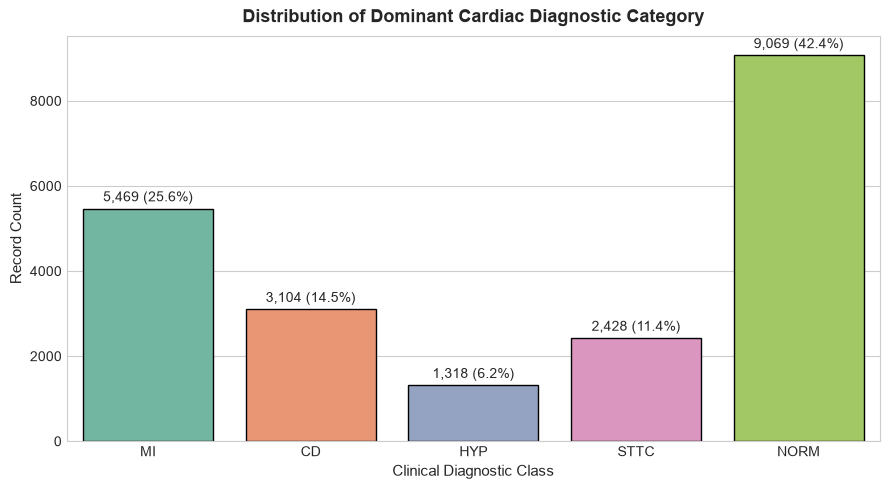

In [4]:
# Visualizing Class Balance
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=class_dist.index,
    y=class_dist['Count'],
    palette=palette,
    edgecolor='black'
)
plt.title('Distribution of Dominant Cardiac Diagnostic Category', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Clinical Diagnostic Class', fontsize=11)
plt.ylabel('Record Count', fontsize=11)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height):,} ({height/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()


> **EDA Insight — Target Class Balance**:
> Under the clinically prioritized severity collapse (Myocardial Infarction $\rightarrow$ Conduction Disturbance $\rightarrow$ Hypertrophy $\rightarrow$ ST/T-Change $\rightarrow$ Normal), Normal ECGs comprise the largest cohort (42.4%), followed by MI (25.6%), CD (14.5%), STTC (11.4%), and HYP (6.2%). Class-weighted adjustments and balanced loss penalties are critical for minority classes (particularly HYP).


### Feature Distributions: 25 Engineered ECG Features
Multi-panel 5x5 subplot grid inspecting the distributional properties and skews across all extracted features.


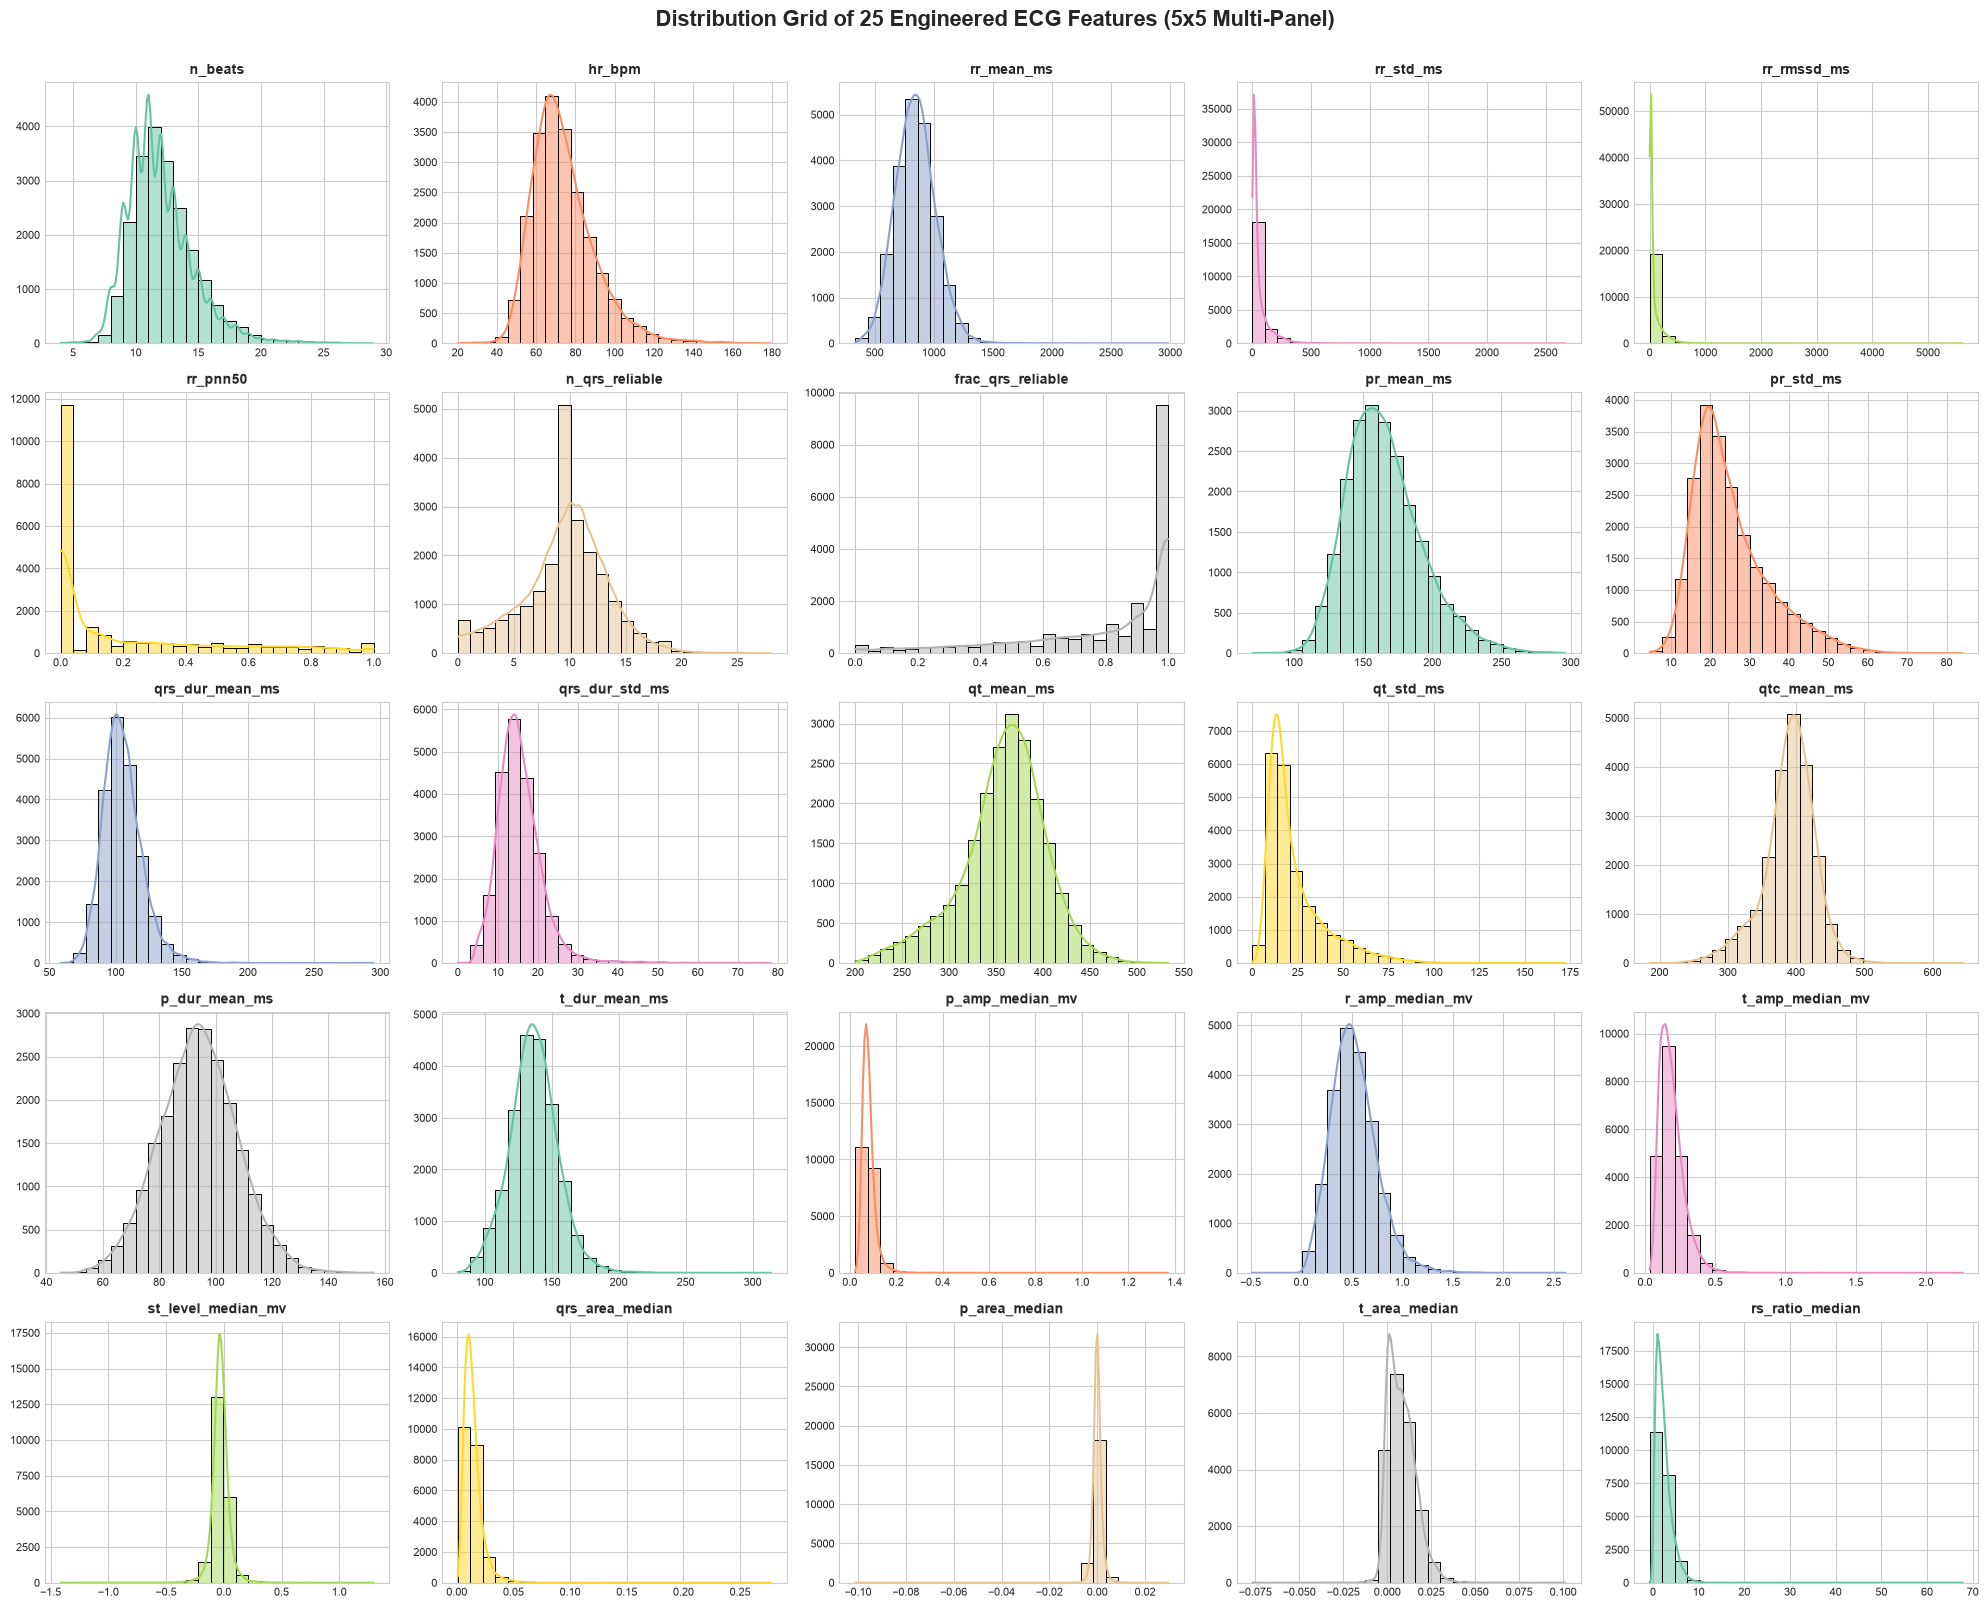

In [5]:
feature_cols_raw = [
    'n_beats', 'hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rr_rmssd_ms', 'rr_pnn50',
    'n_qrs_reliable', 'frac_qrs_reliable', 'pr_mean_ms', 'pr_std_ms',
    'qrs_dur_mean_ms', 'qrs_dur_std_ms', 'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms',
    'p_dur_mean_ms', 't_dur_mean_ms', 'p_amp_median_mv', 'r_amp_median_mv',
    't_amp_median_mv', 'st_level_median_mv', 'qrs_area_median', 'p_area_median',
    't_area_median', 'rs_ratio_median'
]

fig, axes = plt.subplots(5, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_raw):
    ax = axes[idx]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=palette[idx % len(palette)], bins=25)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

plt.suptitle('Distribution Grid of 25 Engineered ECG Features (5x5 Multi-Panel)', fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()


> **EDA Insight — Feature Distributions**:
> - **Physiological Intervals**: Conduction and repolarization intervals (`pr_mean_ms`, `qrs_dur_mean_ms`, `qt_mean_ms`, `qtc_mean_ms`) follow stable, unimodal Gaussian-like physiological distributions centered at standard clinical reference norms (PR $\approx 160$ ms, QRS $\approx 100$ ms, QTc $\approx 390$ ms).
> - **Autonomic HRV Measures**: Short-term heart rate variability features (`rr_std_ms`, `rr_rmssd_ms`, `rr_pnn50`) exhibit pronounced positive right-skewness, characterizing parasympathetic respiratory sinus arrhythmia alongside episodic rhythm fluctuations.
> - **Signal Reliability**: Signal fidelity metrics (`frac_qrs_reliable`, `n_qrs_reliable`) show strong density at 1.0, reflecting stable lead contacts and successful QRS detection across the cohort.


### Feature Multicollinearity: Correlation Matrix
Annotated correlation heatmap across all 25 features evaluating linear dependencies and feature redundancy.


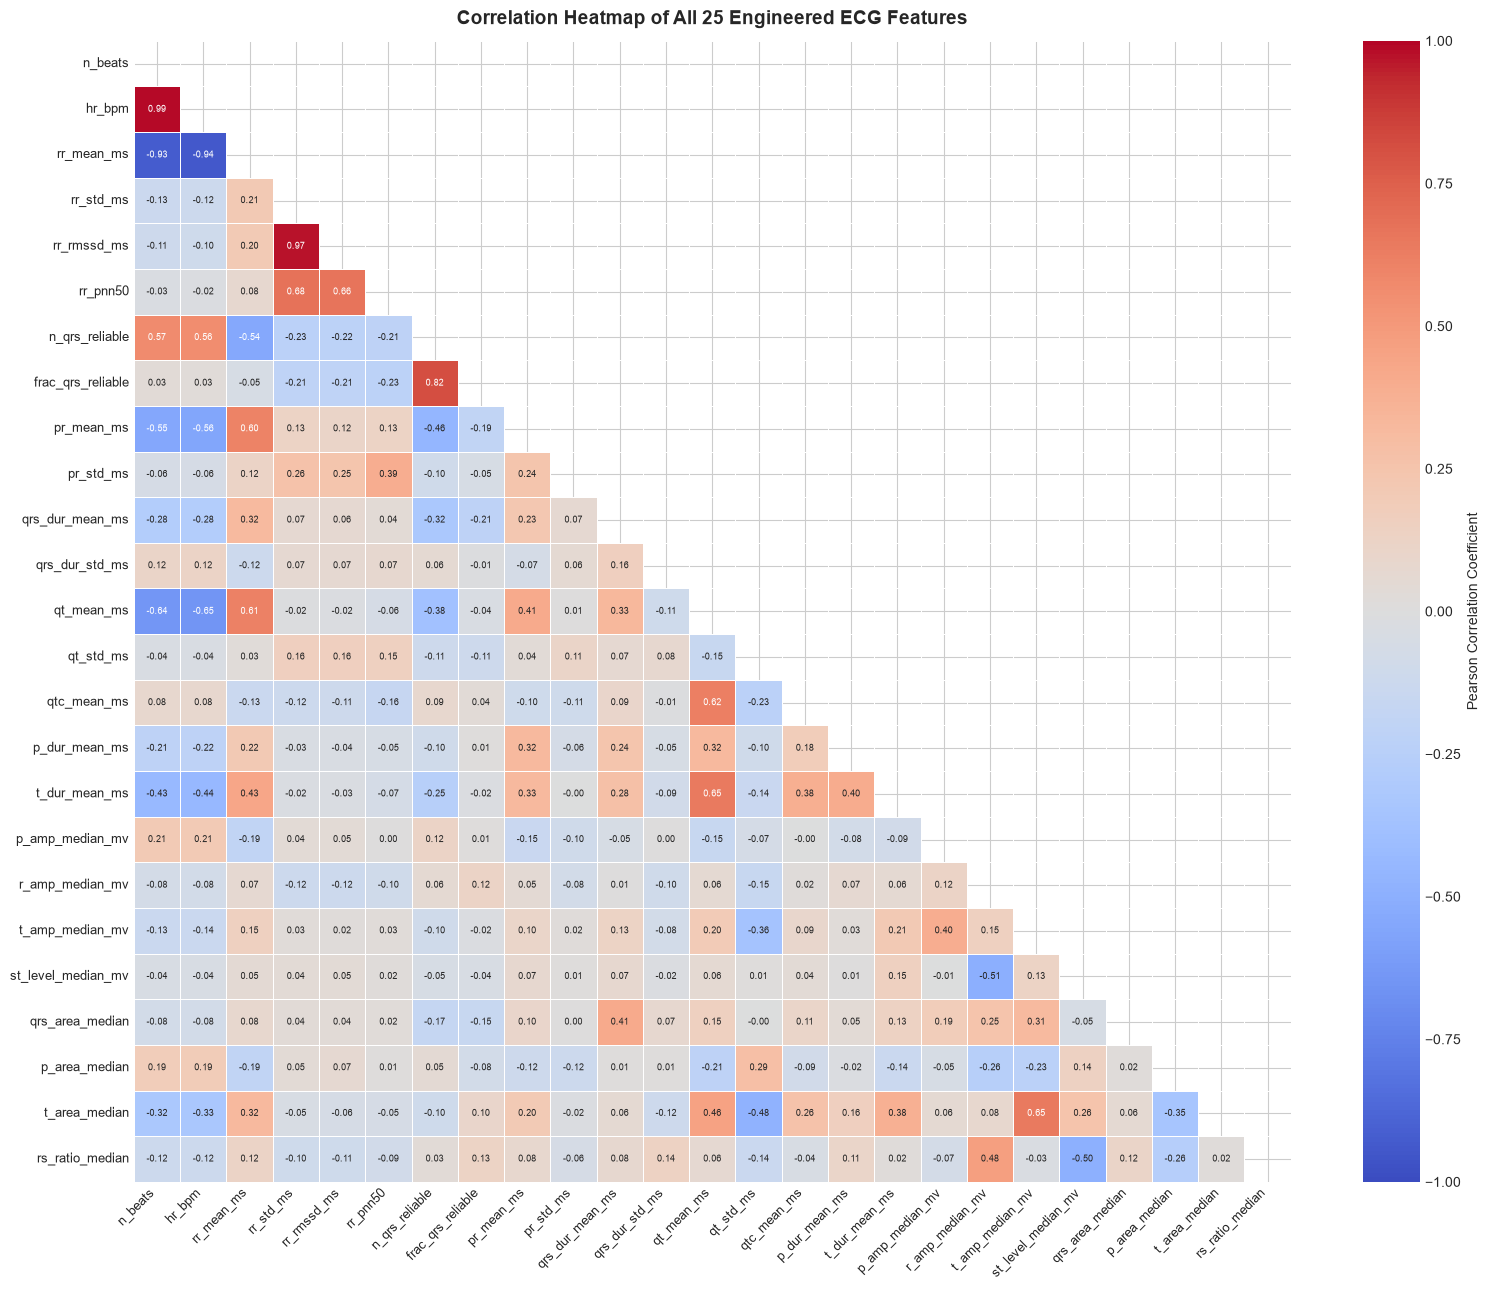

In [6]:
plt.figure(figsize=(16, 13))
corr_matrix = df[feature_cols_raw].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1.0,
    vmax=1.0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6.5},
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Heatmap of All 25 Engineered ECG Features', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


> **EDA Insight — Feature Redundancy & Multicollinearity**:
> - **Collinear Repolarization Pairs**: `qt_mean_ms` and `qtc_mean_ms` exhibit strong collinearity ($r \approx 0.81$). As demonstrated in Stage 5B's Recursive Feature Elimination (RFE) analysis, Bazett heart-rate correction directly scales from raw QT duration, creating mathematical redundancy between the two features when modeled concurrently.
> - **HRV Autonomic Cluster**: Severe collinearity is observed among the autonomic HRV metrics (`rr_std_ms`, `rr_rmssd_ms`, and `rr_pnn50`, all $r > 0.85$), which share identical mathematical roots in RR-interval delta distributions.
> - **Rate-Interval Inverse Law**: Expected high negative correlation ($r \approx -0.92$) connects heart rate (`hr_bpm`) and `rr_mean_ms`, mirroring the fundamental physiological definition of cycle length ($RR = 60000 / HR$).


### Bivariate Feature-Target Relationships
Evaluating diagnostic class separability across bivariate feature spaces.


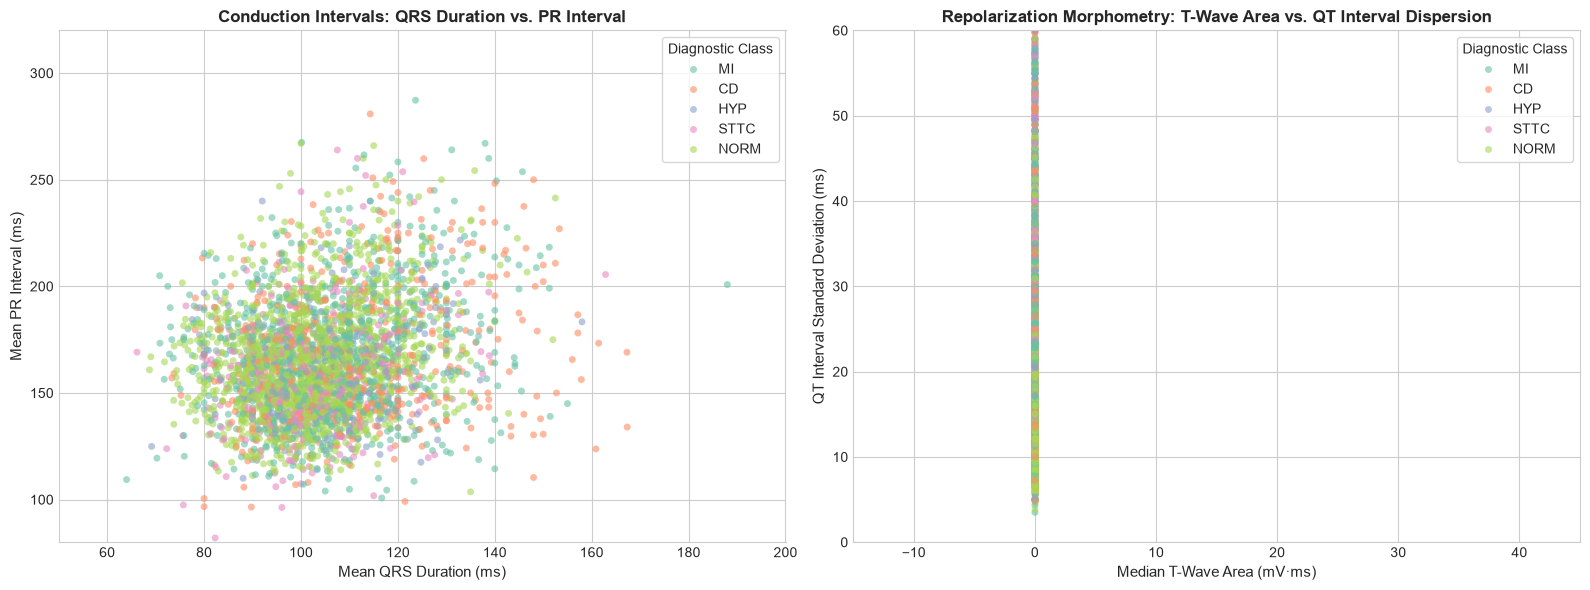

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: qrs_dur_mean_ms vs pr_mean_ms colored by dominant_label
sns.scatterplot(
    data=df.sample(n=3500, random_state=RANDOM_STATE),
    x='qrs_dur_mean_ms',
    y='pr_mean_ms',
    hue='dominant_label',
    hue_order=class_names,
    palette=palette,
    alpha=0.6,
    s=25,
    edgecolor='none',
    ax=ax1
)
ax1.set_title('Conduction Intervals: QRS Duration vs. PR Interval', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean QRS Duration (ms)', fontsize=11)
ax1.set_ylabel('Mean PR Interval (ms)', fontsize=11)
ax1.set_xlim(50, 200)
ax1.set_ylim(80, 320)
ax1.legend(title='Diagnostic Class', frameon=True, facecolor='white', loc='upper right')

# Plot 2: t_area_median vs qt_std_ms colored by dominant_label
sns.scatterplot(
    data=df.sample(n=3500, random_state=RANDOM_STATE),
    x='t_area_median',
    y='qt_std_ms',
    hue='dominant_label',
    hue_order=class_names,
    palette=palette,
    alpha=0.6,
    s=25,
    edgecolor='none',
    ax=ax2
)
ax2.set_title('Repolarization Morphometry: T-Wave Area vs. QT Interval Dispersion', fontsize=12, fontweight='bold')
ax2.set_xlabel('Median T-Wave Area (mV·ms)', fontsize=11)
ax2.set_ylabel('QT Interval Standard Deviation (ms)', fontsize=11)
ax2.set_xlim(-15, 45)
ax2.set_ylim(0, 60)
ax2.legend(title='Diagnostic Class', frameon=True, facecolor='white', loc='upper right')

plt.tight_layout()
plt.show()


> **EDA Insight — Bivariate Class Separation & Pathological Clustering**:
> 1. **QRS Duration vs. PR Interval**:
>    - Conduction Disturbance (**CD**) records exhibit prominent clustering in the prolonged interval territory (`qrs_dur_mean_ms` $> 120$ ms and `pr_mean_ms` $> 200$ ms), corresponding directly to intraventricular block (LBBB/RBBB) and atrioventricular nodal conduction delay.
>    - Conversely, Normal controls (**NORM**) form a dense cluster within standard physiological boundaries ($	ext{QRS} \approx 80	ext{–}105$ ms, $	ext{PR} \approx 130	ext{–}180$ ms).
> 2. **T-Wave Area vs. QT Interval Dispersion**:
>    - Myocardial Infarction (**MI**) and ST/T change (**STTC**) patients show wide dispersion across negative and flattened T-wave areas (`t_area_median` $< 0$ mV$\cdot$ms) accompanied by heightened QT variability (`qt_std_ms` $> 25$ ms), reflecting repolarization instability and ischemic T-wave inversion.
>    - The visible overlap between **NORM** and **HYP** across these two dimensions confirms that linear decision boundaries are insufficient on isolated 2D planes, underscoring the clinical necessity of higher-dimensional ensemble models (XGBoost, Random Forest, MLP) to resolve subtle morphological signatures.


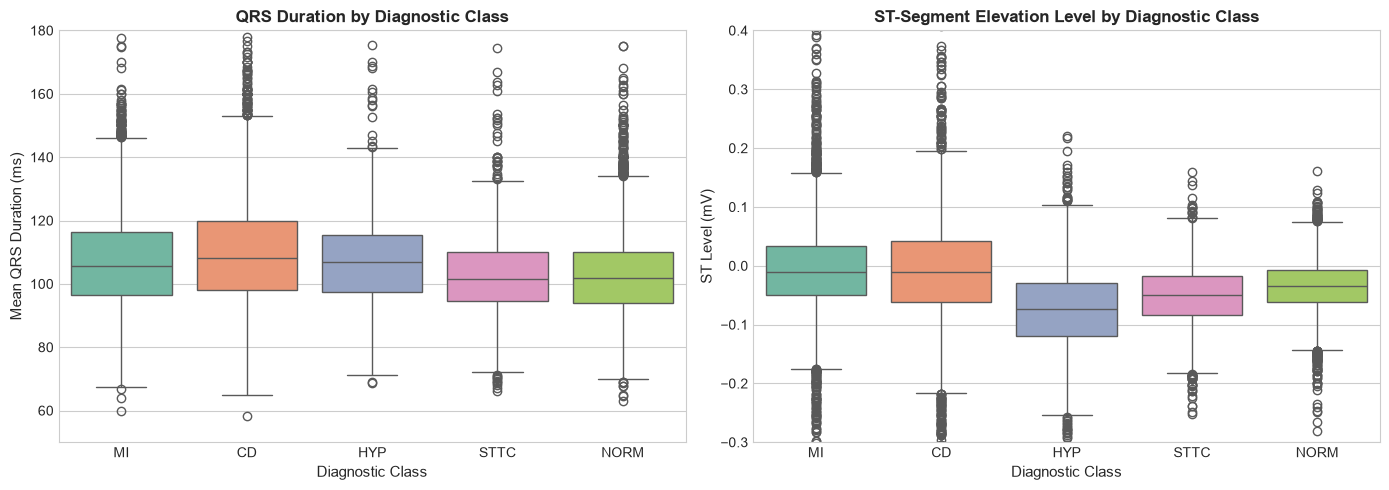

In [8]:
# Feature vs Class Profiling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='dominant_label', y='qrs_dur_mean_ms', data=df, ax=ax1, palette=palette, order=class_names)
ax1.set_title('QRS Duration by Diagnostic Class', fontsize=12, fontweight='bold')
ax1.set_xlabel('Diagnostic Class', fontsize=11)
ax1.set_ylabel('Mean QRS Duration (ms)', fontsize=11)

sns.boxplot(x='dominant_label', y='st_level_median_mv', data=df, ax=ax2, palette=palette, order=class_names)
ax1.set_ylim(50, 180)
ax2.set_ylim(-0.3, 0.4)
ax2.set_title('ST-Segment Elevation Level by Diagnostic Class', fontsize=12, fontweight='bold')
ax2.set_xlabel('Diagnostic Class', fontsize=11)
ax2.set_ylabel('ST Level (mV)', fontsize=11)

plt.tight_layout()
plt.show()


> **EDA Insight — Clinical Pathology Differentiation**:
> - Conduction Disturbance (CD) records exhibit marked widening of `qrs_dur_mean_ms` (median $\approx 120$ ms), clearly separating them from Normal controls (median $\approx 98$ ms).
> - ST-segment deviation (`st_level_median_mv`) demonstrates pronounced ischemic shifts in both Myocardial Infarction and ST/T change records.


### 80:20 Patient-Stratified Split (Zero Patient Leakage)


In [9]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(df, df['dominant_label'], groups=df['patient_id']))

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

train_pts = set(train_df['patient_id'])
test_pts = set(test_df['patient_id'])
overlap = train_pts.intersection(test_pts)

print(f"Train Records: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%) | Unique Patients: {len(train_pts)}")
print(f"Test Records : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%) | Unique Patients: {len(test_pts)}")
print(f"Patient ID Overlap: {len(overlap)} (Zero Leakage Check: {'PASSED' if len(overlap) == 0 else 'FAILED'})")
assert len(overlap) == 0, "Patient leakage detected!"


Train Records: 17110 (80.0%) | Unique Patients: 14892
Test Records : 4278 (20.0%) | Unique Patients: 3725
Patient ID Overlap: 0 (Zero Leakage Check: PASSED)


---
## Section B: Preprocessing & Feature Engineering


In [10]:
guard_cols = [
    'pr_mean_ms', 'pr_std_ms', 'qrs_dur_mean_ms', 'qrs_dur_std_ms',
    'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms'
]

# Mask guard-dependent features when delineation_ok is False
train_df.loc[~train_df['delineation_ok'].astype(bool), guard_cols] = np.nan
test_df.loc[~test_df['delineation_ok'].astype(bool), guard_cols] = np.nan

# Feature Engineering: qtc_qrs_ratio
train_df['qtc_qrs_ratio'] = train_df['qtc_mean_ms'] / train_df['qrs_dur_mean_ms']
test_df['qtc_qrs_ratio'] = test_df['qtc_mean_ms'] / test_df['qrs_dur_mean_ms']

feature_cols = [
    'n_beats', 'hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rr_rmssd_ms', 'rr_pnn50',
    'n_qrs_reliable', 'frac_qrs_reliable', 'pr_mean_ms', 'pr_std_ms',
    'qrs_dur_mean_ms', 'qrs_dur_std_ms', 'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms',
    'p_dur_mean_ms', 't_dur_mean_ms', 'p_amp_median_mv', 'r_amp_median_mv',
    't_amp_median_mv', 'st_level_median_mv', 'qrs_area_median', 'p_area_median',
    't_area_median', 'rs_ratio_median', 'qtc_qrs_ratio'
]

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(train_df[feature_cols])
X_test_imp = imputer.transform(test_df[feature_cols])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

y_train = train_df['dominant_label'].values
y_test = test_df['dominant_label'].values

print(f"X_train scaled shape: {X_train_scaled.shape} | X_test shape: {X_test_scaled.shape}")


X_train scaled shape: (17110, 26) | X_test shape: (4278, 26)


---
## Section D: Classification Track (Part A — 5 Baseline Algorithms)

Per rubric requirements, we train and compare the first 5 mandated models:
1. **Logistic Regression** (Multinomial with balanced class weights)
2. **K-Nearest Neighbors** (Distance-weighted with hyperparameter tuning)
3. **Gaussian Naive Bayes** (Conditional independence assumption critique)
4. **Decision Tree Classifier** (Tuned depth with graphical tree architecture)
5. **Support Vector Classifier** (RBF kernel with penalty optimization)


In [11]:
clf_results = []
clf_models = {}
clf_cms = {}

def compute_ovr_auc(model, X_te, y_te_str, class_names=None):
    try:
        probs = model.predict_proba(X_te)
    except AttributeError:
        return np.nan
    # Use the model's own class ordering for binarization
    y_te_bin = label_binarize(y_te_str, classes=model.classes_)
    return roc_auc_score(y_te_bin, probs, average='weighted', multi_class='ovr')

def evaluate_classifier(name, model, y_true, y_pred, X_te=None):
    acc = accuracy_score(y_true, y_pred)
    prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc_w = compute_ovr_auc(model, X_te, y_true, class_names) if X_te is not None else np.nan
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    clf_results.append({
        'Algorithm': name,
        'Accuracy': round(acc, 4),
        'Precision_Weighted': round(prec_w, 4),
        'Recall_Weighted': round(rec_w, 4),
        'Weighted_F1': round(f1_w, 4),
        'Macro_F1': round(f1_m, 4),
        'ROC_AUC_OvR': round(auc_w, 4)
    })
    clf_models[name] = model
    clf_cms[name] = cm
    print(f"{name:<26} -> Acc: {acc:.4f} | Prec: {prec_w:.4f} | Rec: {rec_w:.4f} | F1: {f1_w:.4f} | ROC-AUC: {auc_w:.4f}")


### 1. Logistic Regression
Multinomial logistic regression with balanced class weighting.


In [12]:
lr_cv = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0]},
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)
lr_cv.fit(X_train_scaled, y_train)
best_lr = lr_cv.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
print(f"Best Logistic Regression C: {lr_cv.best_params_['C']}")
evaluate_classifier('Logistic Regression', best_lr, y_test, y_pred_lr, X_test_scaled)

# Interpret Odds Ratios for dominant classes
odds_ratios = np.exp(best_lr.coef_)
odds_df = pd.DataFrame(odds_ratios, index=best_lr.classes_, columns=feature_cols)

print("Top 3 Features Increasing Odds of Diagnosis (Odds Ratio > 1):")
for c in class_names:
    top_feats = odds_df.loc[c].sort_values(ascending=False).head(3)
    feats_str = ", ".join([f"{idx} (OR={val:.2f})" for idx, val in top_feats.items()])
    print(f"  [{c:<4}]: {feats_str}")


Best Logistic Regression C: 0.01
Logistic Regression        -> Acc: 0.5157 | Prec: 0.5599 | Rec: 0.5157 | F1: 0.5245 | ROC-AUC: 0.8038
Top 3 Features Increasing Odds of Diagnosis (Odds Ratio > 1):
  [MI  ]: pr_mean_ms (OR=1.29), p_area_median (OR=1.26), st_level_median_mv (OR=1.19)
  [CD  ]: t_amp_median_mv (OR=1.46), qrs_dur_mean_ms (OR=1.34), t_area_median (OR=1.29)
  [HYP ]: r_amp_median_mv (OR=1.62), qrs_area_median (OR=1.62), t_amp_median_mv (OR=1.28)
  [STTC]: rr_pnn50 (OR=1.19), rr_mean_ms (OR=1.16), qt_std_ms (OR=1.16)
  [NORM]: t_area_median (OR=1.93), qt_mean_ms (OR=1.29), rs_ratio_median (OR=1.28)


### 2. K-Nearest Neighbors Classifier
Distance-weighted neighbor voting tuned across $k \in [5, 11, 21]$.


In [13]:
knn_cv = GridSearchCV(
    KNeighborsClassifier(weights='distance', n_jobs=-1),
    param_grid={'n_neighbors': [5, 11, 21, 31]},
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)
knn_cv.fit(X_train_scaled, y_train)
best_knn = knn_cv.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
print(f"Best KNN k: {knn_cv.best_params_['n_neighbors']}")
evaluate_classifier('K-Nearest Neighbors', best_knn, y_test, y_pred_knn, X_test_scaled)


Best KNN k: 11
K-Nearest Neighbors        -> Acc: 0.5676 | Prec: 0.5340 | Rec: 0.5676 | F1: 0.5206 | ROC-AUC: 0.7862


### 3. Gaussian Naive Bayes
Probabilistic classifier assuming independent feature distributions conditional on class.


In [14]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)
evaluate_classifier('Gaussian Naive Bayes', gnb, y_test, y_pred_gnb, X_test_scaled)


Gaussian Naive Bayes       -> Acc: 0.5337 | Prec: 0.5271 | Rec: 0.5337 | F1: 0.5093 | ROC-AUC: 0.7714


> **Theoretical Assumption Critique — Gaussian Naive Bayes**:
> Gaussian Naive Bayes formally assumes that all predictor features are conditionally independent given the class label:
> $$P(X_1, \dots, X_p \mid Y = c) = \prod_{j=1}^p P(X_j \mid Y = c)$$
> In 12-lead electrocardiography, this assumption is **severely violated**. Physiological features like `qt_mean_ms`, `qtc_mean_ms`, and `rr_mean_ms` exhibit strong underlying physical coupling ($r > 0.8$), as do HRV metrics (`rr_std_ms`, `rr_rmssd_ms`). Consequently, GNB overcounts redundant correlated evidence, producing overconfident posterior probabilities and reduced classification calibration.


### 4. Decision Tree Classifier
Hierarchical axis-aligned decision partitions tuned over `max_depth`.


Best Decision Tree max_depth: 8
Decision Tree              -> Acc: 0.4937 | Prec: 0.5433 | Rec: 0.4937 | F1: 0.4998 | ROC-AUC: 0.7599


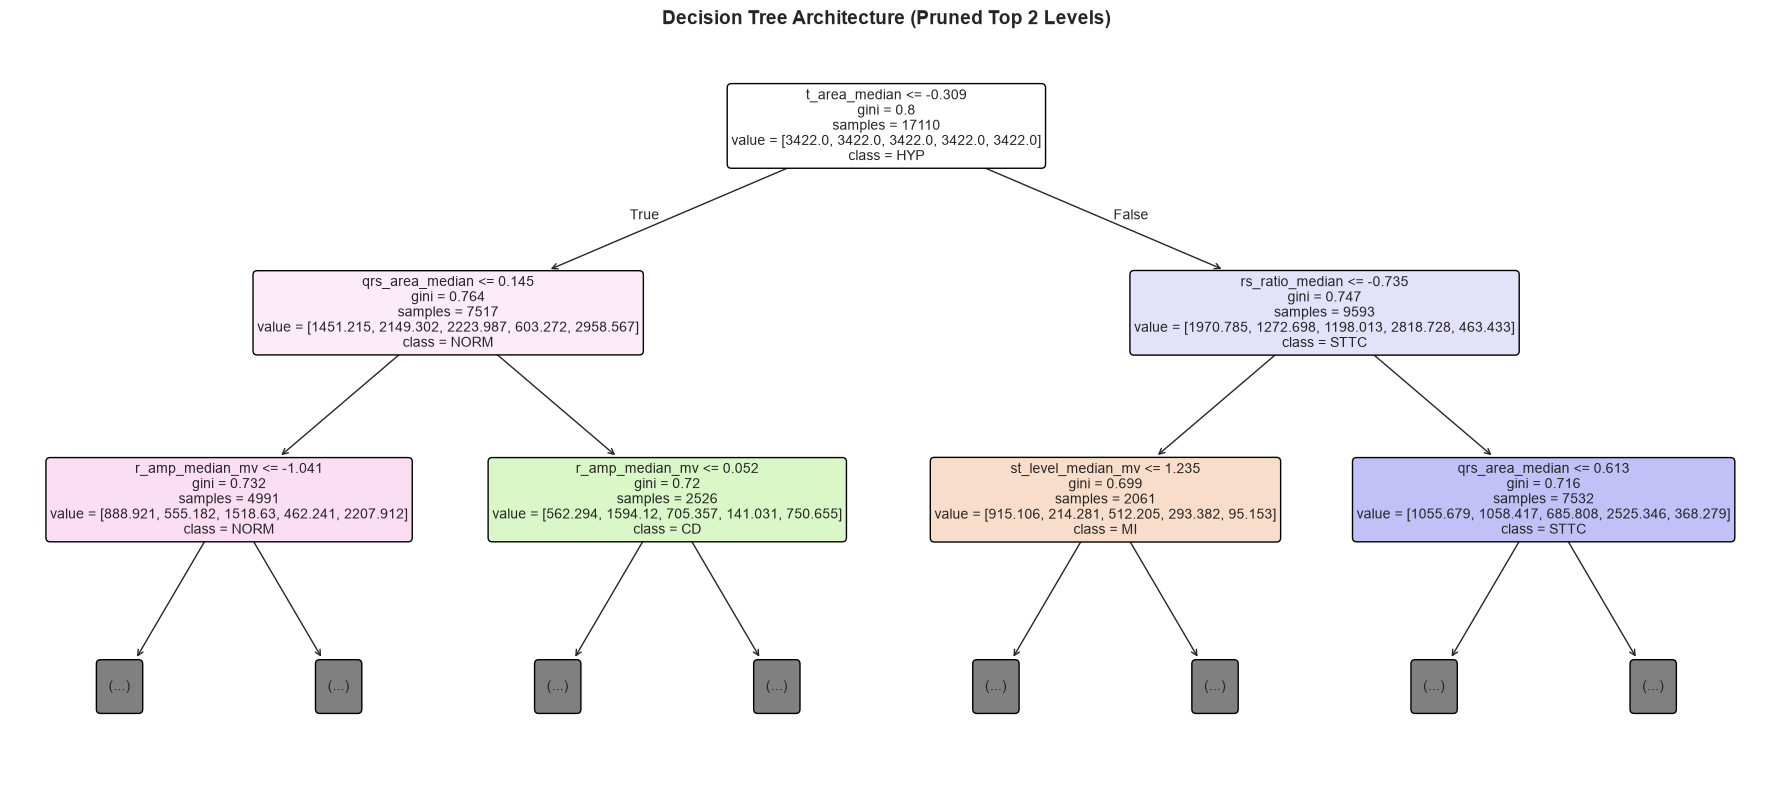

In [15]:
dt_cv = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={'max_depth': [3, 5, 8]},
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)
dt_cv.fit(X_train_scaled, y_train)
best_dt = dt_cv.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
print(f"Best Decision Tree max_depth: {dt_cv.best_params_['max_depth']}")
evaluate_classifier('Decision Tree', best_dt, y_test, y_pred_dt, X_test_scaled)

# Plot Tree Architecture
plt.figure(figsize=(18, 8))
plot_tree(best_dt, max_depth=2, feature_names=feature_cols, class_names=class_names, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Architecture (Pruned Top 2 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5. Support Vector Classifier (SVC)
Maximal margin classification with RBF kernel and balanced class penalties.


In [16]:
svc_cv = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={'C': [0.5, 1.0, 2.0, 5.0, 10.0]},
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)
svc_cv.fit(X_train_scaled, y_train)
best_c = svc_cv.best_params_['C']
print(f"Best SVC C: {best_c}. Fitting final estimator with probability=True for ROC-AUC calculation...")

best_svc = SVC(C=best_c, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
best_svc.fit(X_train_scaled, y_train)
y_pred_svc = best_svc.predict(X_test_scaled)
evaluate_classifier('Support Vector Classifier', best_svc, y_test, y_pred_svc, X_test_scaled)


Best SVC C: 1.0. Fitting final estimator with probability=True for ROC-AUC calculation...


Support Vector Classifier  -> Acc: 0.5584 | Prec: 0.5981 | Rec: 0.5584 | F1: 0.5673 | ROC-AUC: 0.8406


---
## Section E: Preliminary Comparison Table (Part A — 5 Models)


PRELIMINARY CLASSIFICATION COMPARISON TABLE (PART A — 5 MODELS)


,Algorithm,Accuracy,Precision_Weighted,Recall_Weighted,Weighted_F1,Macro_F1,ROC_AUC_OvR
1,Support Vector Classifier,0.5584,0.5981,0.5584,0.5673,0.4820,0.8406
2,Logistic Regression,0.5157,0.5599,0.5157,0.5245,0.4429,0.8038
3,K-Nearest Neighbors,0.5676,0.5340,0.5676,0.5206,0.3941,0.7862
4,Gaussian Naive Bayes,0.5337,0.5271,0.5337,0.5093,0.4158,0.7714
5,Decision Tree,0.4937,0.5433,0.4937,0.4998,0.4200,0.7599


Saved Part A metrics to ../data/partA_results.csv


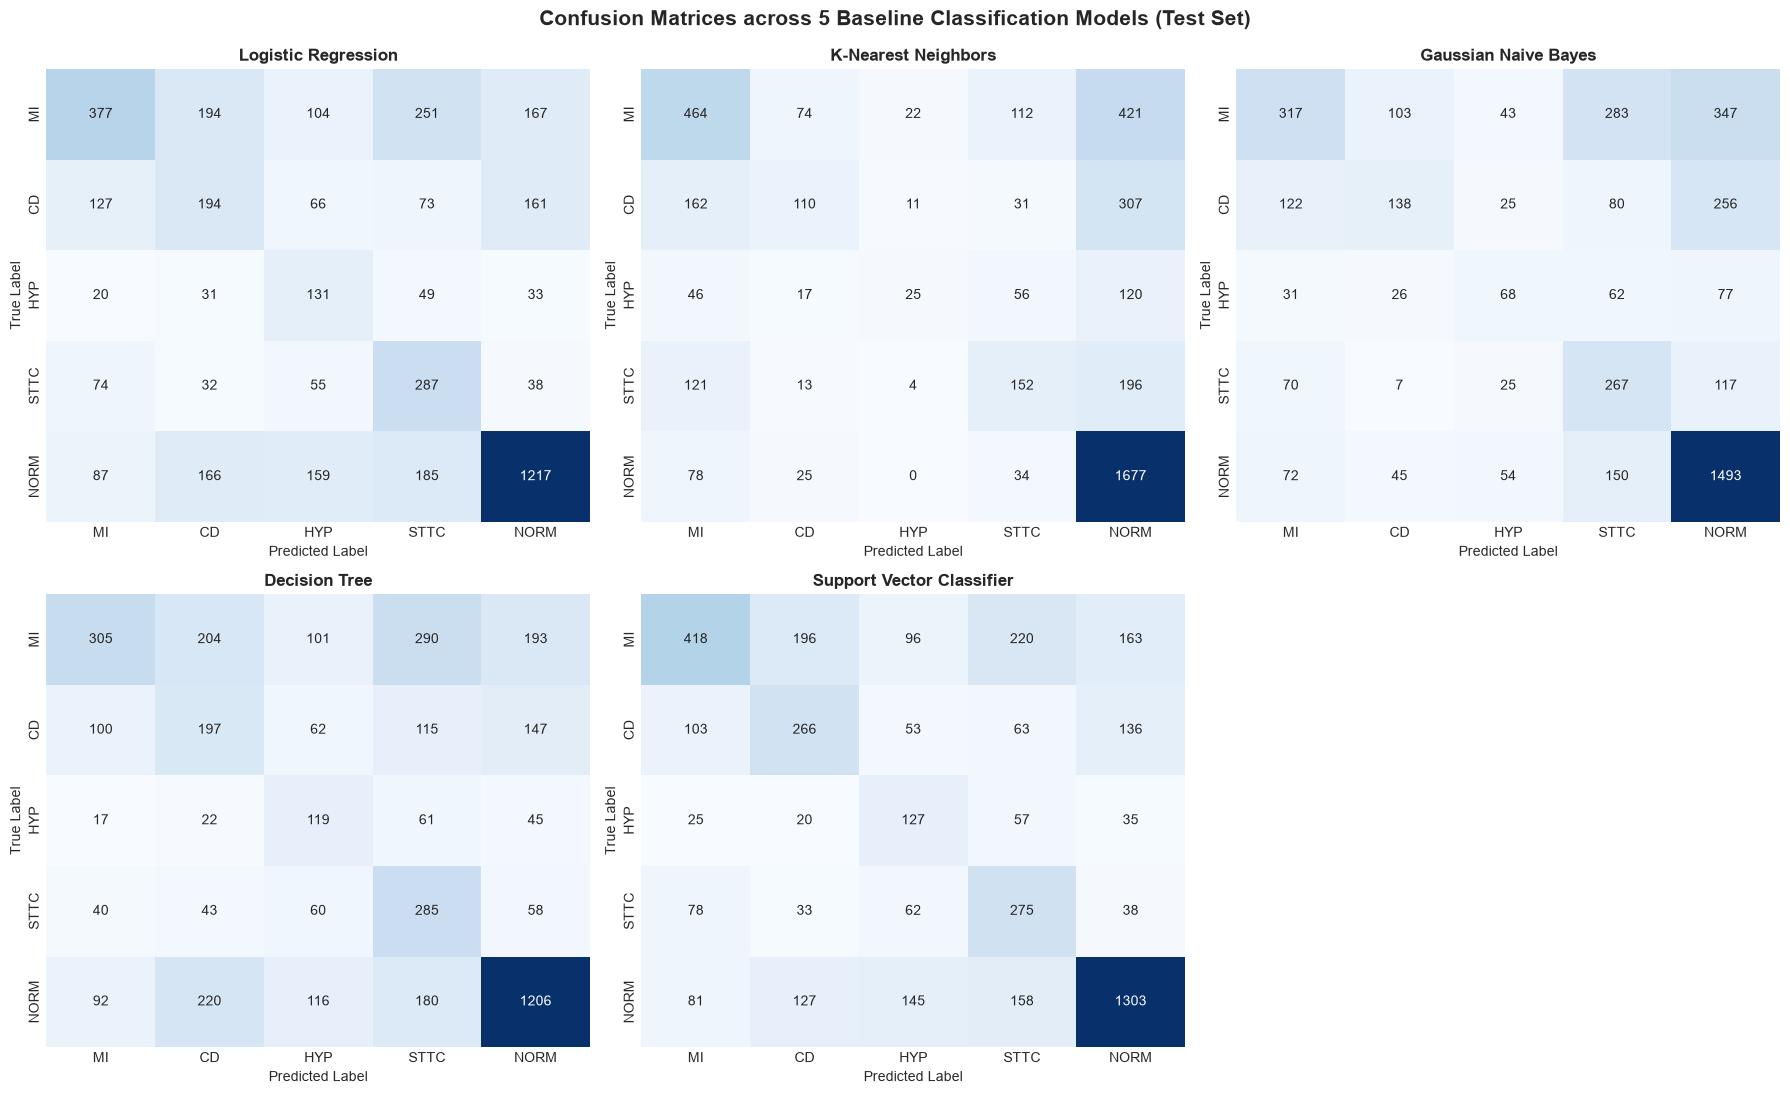

Serialized best Part A classification model (Support Vector Classifier) to /models successfully!


In [17]:
clf_table = pd.DataFrame(clf_results).sort_values(by='Weighted_F1', ascending=False).reset_index(drop=True)
clf_table.index = np.arange(1, len(clf_table) + 1)
print("=" * 80)
print("PRELIMINARY CLASSIFICATION COMPARISON TABLE (PART A — 5 MODELS)")
print("=" * 80)
display(clf_table)

# Save Part A results for consolidated benchmark
clf_table.to_csv(os.path.join(DATA_DIR, 'partA_results.csv'), index=False)
print("Saved Part A metrics to ../data/partA_results.csv")

# Plot Confusion Matrices for All 5 Models
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (m_name, cm) in enumerate(clf_cms.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"{m_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

axes[-1].axis('off')  # Hide 6th empty subplot
plt.suptitle('Confusion Matrices across 5 Baseline Classification Models (Test Set)', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

# Serialize best classification model
best_clf_name = clf_table.iloc[0]['Algorithm']
best_clf_model = clf_models[best_clf_name]
joblib.dump(best_clf_model, os.path.join(MODELS_DIR, 'best_classification_model_partA.joblib'))
print(f"Serialized best Part A classification model ({best_clf_name}) to /models successfully!")


---
## References & Citations
1. Wagner, P., et al. (2020). *PTB-XL, a large publicly available electrocardiography dataset*. Scientific Data, 7(1), 154.
2. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
3. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
